In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (Input, Embedding, SpatialDropout1D, Conv1D, 
                                     MaxPooling1D, LSTM, Dense, Dropout, 
                                     BatchNormalization)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, precision_recall_fscore_support, 
                             roc_curve, auc)
import gensim.downloader as api

# Downloads
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\heman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\heman\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Load Dataset
df = pd.read_csv(r".\Combined Data.csv")
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
df.dropna(inplace=True)

# Resampling to Balance all 7 Classes
def resample_data(df):
    max_count = df['status'].value_counts().max()
    df_resampled = pd.DataFrame()
    for status in df['status'].unique():
        df_class = df[df['status'] == status]
        df_class_resampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
        df_resampled = pd.concat([df_resampled, df_class_resampled])
    return df_resampled

df = resample_data(df)
print("Balanced Classes:\n", df['status'].value_counts())

Balanced Classes:
 status
Anxiety                 16343
Normal                  16343
Depression              16343
Suicidal                16343
Stress                  16343
Bipolar                 16343
Personality disorder    16343
Name: count, dtype: int64


In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z0-9\s]', '', str(text).lower())
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['statement'] = df['statement'].apply(preprocess_text)

# Label Encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['status'].values)
y_categorical = to_categorical(y_encoded)

# Split (90-10)
X_train, X_test, y_train, y_test = train_test_split(df['statement'].values, y_categorical, test_size=0.1, random_state=42)

# Tokenization
max_words = 50000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_padded = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding='post')
X_test_padded = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len, padding='post')

In [7]:
print("Loading Word2Vec model...")
word2vec_model = api.load("word2vec-google-news-300")
embedding_dim = 300
num_words = min(max_words, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < max_words:
        if word in word2vec_model:
            embedding_matrix[i] = word2vec_model[word]
        else:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
print("Embedding Matrix ready.")

Loading Word2Vec model...
Embedding Matrix ready.


In [8]:
def build_cnn_lstm():
    model = Sequential([
        Embedding(num_words, embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(0.3),
        
        # CNN Part: Extracting local features (trigger phrases)
        Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
        MaxPooling1D(pool_size=4),
        
        # LSTM Part: Understanding emotional sequence
        LSTM(128, dropout=0.2, recurrent_dropout=0.2),
        
        # Fully Connected Layers
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(7, activation='softmax')
    ], name="CNN_LSTM_Model")
    return model

model = build_cnn_lstm()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()




Model: "CNN_LSTM_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 300)          15000000  
                                                                 
 spatial_dropout1d (Spatial  (None, 100, 300)          0         
 Dropout1D)                                                      
                                                                 
 conv1d (Conv1D)             (None, 100, 128)          192128    
                                                                 
 max_pooling1d (MaxPooling1  (None, 25, 128)           0         
 D)                                                              
                                                                 
 lstm (LSTM)                 (None, 128)               131584    
                                                                 
 dense (Dense)               (None, 128)         

In [28]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history = model.fit(
    X_train_padded, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=callbacks
)

# Saving as requested
model.save("sentiment analysis_cnn_lstm.keras")
model.save("cnn_lstm_model.h5")
print("CNN-LSTM Model saved successfully.")

Epoch 1/15
724/724 [==============================] - 86s 119ms/step - loss: 0.1634 - accuracy: 0.9400 - val_loss: 0.1814 - val_accuracy: 0.9389 - lr: 5.0000e-04
Epoch 2/15
724/724 [==============================] - 86s 119ms/step - loss: 0.1603 - accuracy: 0.9414 - val_loss: 0.1801 - val_accuracy: 0.9375 - lr: 5.0000e-04
Epoch 3/15
724/724 [==============================] - 87s 120ms/step - loss: 0.1577 - accuracy: 0.9426 - val_loss: 0.1802 - val_accuracy: 0.9405 - lr: 5.0000e-04
Epoch 4/15
724/724 [==============================] - 87s 120ms/step - loss: 0.1547 - accuracy: 0.9435 - val_loss: 0.1626 - val_accuracy: 0.9421 - lr: 5.0000e-04
Epoch 5/15
724/724 [==============================] - 918s 1s/step - loss: 0.1467 - accuracy: 0.9452 - val_loss: 0.1819 - val_accuracy: 0.9395 - lr: 5.0000e-04
Epoch 6/15
724/724 [==============================] - 2886s 4s/step - loss: 0.1463 - accuracy: 0.9463 - val_loss: 0.1742 - val_accuracy: 0.9462 - lr: 5.0000e-04
Epoch 7/15
724/724 [===========

c:\MH_Sentiment_Project\mh_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


CNN-LSTM Model saved successfully.


In [13]:
y_pred_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics Calculation
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
performance_df = pd.DataFrame({
    'Emotion': label_encoder.classes_,
    'Precision': precision, 'Recall': recall, 'F1-Score': f1
})

print("\n--- CNN-LSTM PERFORMANCE TABLE ---")
print(performance_df)
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

358/358 [==============================] - 4s 9ms/step

--- CNN-LSTM PERFORMANCE TABLE ---
                Emotion  Precision    Recall  F1-Score
0               Anxiety   0.981829  0.991124  0.986455
1               Bipolar   0.987253  0.999355  0.993267
2            Depression   0.886395  0.759324  0.817954
3                Normal   0.947622  0.963870  0.955677
4  Personality disorder   0.988118  1.000000  0.994023
5                Stress   0.981040  0.996273  0.988598
6              Suicidal   0.816768  0.885078  0.849552

--- CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

             Anxiety       0.98      0.99      0.99      1690
             Bipolar       0.99      1.00      0.99      1550
          Depression       0.89      0.76      0.82      1716
              Normal       0.95      0.96      0.96      1633
Personality disorder       0.99      1.00      0.99      1580
              Stress       0.98      1.00      0.99      1610
   

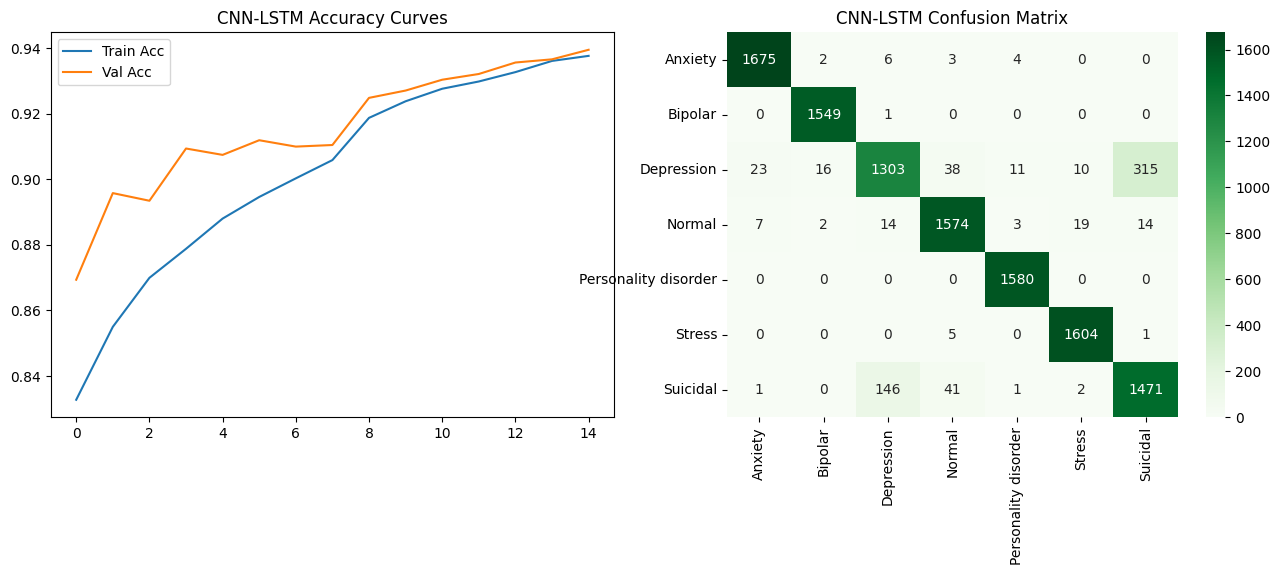

In [14]:
plt.figure(figsize=(16, 5))

# Plot Accuracy & Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('CNN-LSTM Accuracy Curves')
plt.legend()

# Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('CNN-LSTM Confusion Matrix')
plt.show()

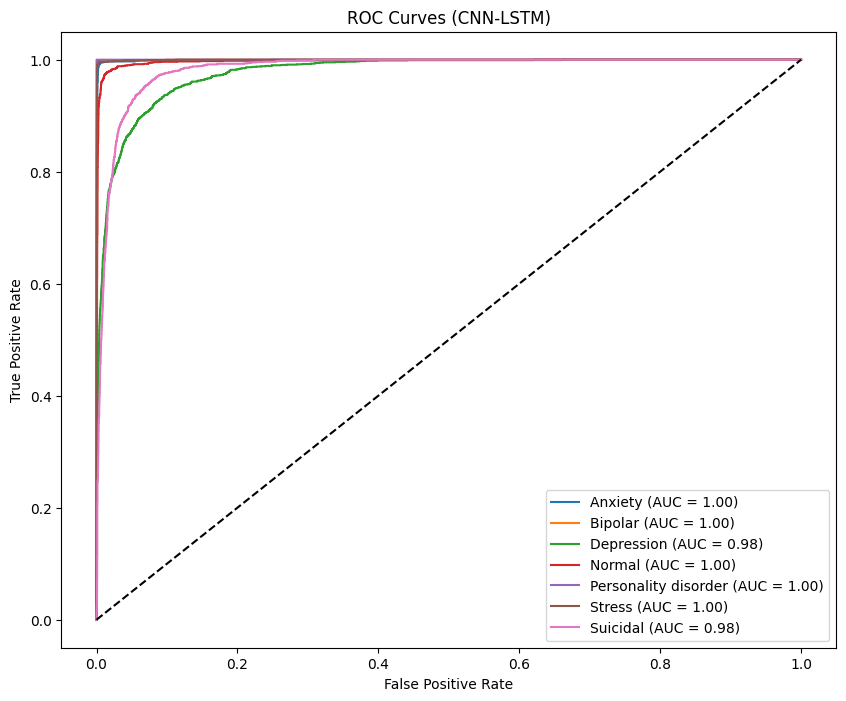

In [15]:
plt.figure(figsize=(10, 8))
for i in range(7):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (CNN-LSTM)')
plt.legend(loc="lower right")
plt.show()

In [1]:
def analyze_mental_health(text):
    clean = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=max_len)
    
    prediction = model.predict(padded, verbose=0)[0]
    idx = np.argmax(prediction)
    conf = prediction[idx]
    
    intensity = "HIGH" if conf > 0.85 else "MODERATE" if conf > 0.65 else "LOW"
    
    print(f"\nResult: {label_encoder.classes_[idx].upper()}")
    print(f"Intensity: {intensity} ({conf*100:.1f}%)")

# Test
analyze_post = "Feeling stressed "
analyze_mental_health(analyze_post)

NameError: name 'preprocess_text' is not defined